In [1]:
# analyze the data from wavy, provided by P. Bohlinger, see:
# https://github.com/jerabaul29/periodic_oscillation_wave_damping_2021_svalbard_waves_in_ice_arven_etter_nansen/issues/34
# "simple" analysis: can the tide explain for what we see?

In [31]:
import os
import time

import netCDF4 as nc4

os.environ["TZ"] = "UTC"
time.tzset()

import datetime

from icecream import ic

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker

import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

import numpy as np

import matplotlib.cm as mplcm
import matplotlib.colors as colors

from data_tools import dict_extracted_data, dict_extracted_data_2018, dict_extracted_data_2021, load_sic
from data_tools import generate_lists_data, instrument_label, ColormapMapper

import cartopy.crs as ccrs
import pyproj

from scipy.interpolate import splprep, splev

from mpl_toolkits.axes_grid1 import host_subplot
import mpl_toolkits.axisartist as AA

import xarray as xa

from joblib import Parallel, delayed

import pickle as pkl

In [3]:
import xarray as xr
import pandas as pd
from pytmd_get_tide_elevation_current import get_pytmd_tide_timeseries
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime
from pathlib import Path
import os
import cartopy.crs as ccrs
import numpy as np
import scipy
import math
import seaborn as sns
import math

In [4]:
# where to look
# NOTE: original location is at: /lustre/storeB/project/fou/om/patrikb/tmp_JR
path_to_satobs = "/home/jrmet/Desktop/Data/sea_ice_oscillatory/PBohlingerSatWaves/tmp_JR/scos/"

# some files are empty, which confuses open_mfdataset; only consider files that are non empty
min_valid_size = 15_000
list_valid_files = list(filter(lambda x: os.path.getsize(x) > min_valid_size, [os.path.join(path_to_satobs, x) for x in os.listdir(path_to_satobs)]))

In [5]:
# xr_satobs = xr.open_mfdataset([path_to_satobs + "sco_JR_20160110.nc"], drop_variables=["latlon"])
xr_satobs = xr.open_mfdataset(list_valid_files, drop_variables=["latlon"])

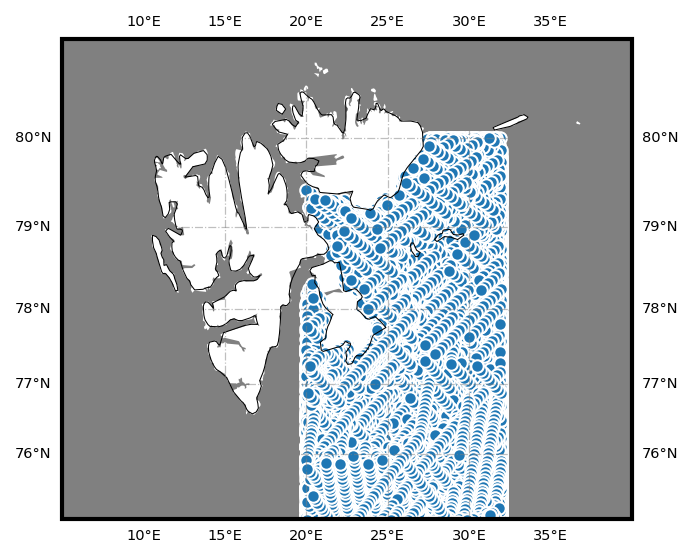

In [6]:
# show where the in-situ measurements are
# these are *all* the in-situ measurements - we will restrict these soon

# --------------------------------------------------
# cartopy map

# First we specify Coordinate Refference System for Map Projection
# We will use Mercator, which is a cylindrical, conformal projection. 
# It has bery large distortion at high latitudes, cannot 
# fully reach the polar regions.
projection = ccrs.Mercator()

# Specify CRS, that will be used to tell the code, where should our data be plotted
crs = ccrs.PlateCarree()

# Now we will create axes object having specific projection 
# make the figure big enough
cm = 1/2.54  # centimeters in inches
plt.figure(dpi=150, figsize=(12*cm, 12*cm))
ax = plt.axes(projection=projection, frameon=True)

# Draw gridlines in degrees over Mercator map
gl = ax.gridlines(crs=crs, draw_labels=True,
                  linewidth=.6, color='gray', alpha=0.5, linestyle='-.')
gl.xlabel_style = {"size" : 7}
gl.ylabel_style = {"size" : 7}

# To plot borders and coastlines, we can use cartopy feature
import cartopy.feature as cf
ax.add_feature(cf.COASTLINE.with_scale("50m"), lw=0.5)
ax.add_feature(cf.BORDERS.with_scale("50m"), lw=0.3)

# Now, we will specify extent of our map in minimum/maximum longitude/latitude
# Note that these values are specified in degrees of longitude and degrees of latitude
# However, we can specify them in any crs that we want, but we need to provide appropriate
# crs argument in ax.set_extent
lon_min = 5
lon_max = 40
lat_min = 75
lat_max = 81

#
ax.add_feature(cf.OCEAN,facecolor=(0.5,0.5,0.5))

xr_satobs.plot.scatter(x="longitude", y="latitude", transform=ccrs.PlateCarree())

# crs is PlateCarree -> we are explicitly telling axes, that we are creating bounds that are in degrees
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=crs)
# plt.title(f"title")
ax.set_title("")

plt.tight_layout()
plt.show()

In [7]:
xr_satobs

<xarray.Dataset>
Dimensions:    (time: 427121)
Coordinates:
  * time       (time) datetime64[ns] 2010-01-01T10:57:33.290022912 ... 2018-1...
Data variables:
    longitude  (time) float64 dask.array<chunksize=(142,), meta=np.ndarray>
    latitude   (time) float64 dask.array<chunksize=(142,), meta=np.ndarray>
    Hs         (time) float64 dask.array<chunksize=(142,), meta=np.ndarray>
Attributes:
    title:           satellite_altimeter observations from multi
    Conventions:     CF-1.6
    institution:     Norwegian Meteorological Institute
    history:         2023-08-07T17:33:29.833782. Created.
    netcdf_version:  NETCDF4
    provider:        cci

In [143]:
mid_lat = 77.5
mid_lon = 25.5

lat_1_degree_to_km = 110
lon_1_degree_to_km = lat_1_degree_to_km * math.cos(math.pi / 180.0 * mid_lat)

print(f"{lat_1_degree_to_km = }")
print(f"{lon_1_degree_to_km = }")
print("")

box_side_km = 60
box_halfside_km = box_side_km / 2.0

lat_halfside = box_halfside_km / lat_1_degree_to_km
lon_halfside = box_halfside_km / lon_1_degree_to_km

print(f"{lat_halfside = }")
print(f"{lon_halfside = }")

lat_1_degree_to_km = 110
lon_1_degree_to_km = 23.80835753319132

lat_halfside = 0.2727272727272727
lon_halfside = 1.2600617223668995


In [144]:
# filter the xarray to keep only the data in the smaller box
xr_reduced = xr_satobs.where(xr_satobs["latitude"]<mid_lat+lat_halfside).where(xr_satobs["latitude"]>mid_lat-lat_halfside).where(xr_satobs["longitude"]<mid_lon+lon_halfside).where(xr_satobs["longitude"]>mid_lon-lon_halfside)
# do the dask magics to actually evaluate
xr_reduced = xr_reduced.where(np.isfinite(xr_reduced["Hs"]).compute(), drop=True).squeeze()

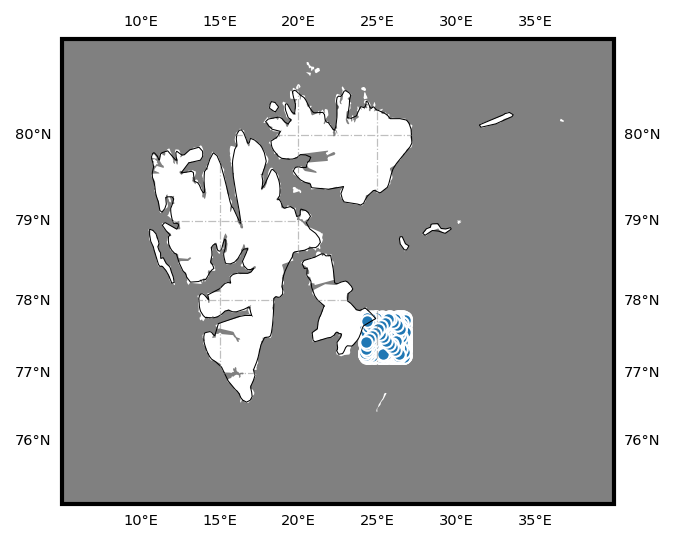

In [145]:
# show where the restricted in-situ measurements are

# --------------------------------------------------
# cartopy map

# First we specify Coordinate Refference System for Map Projection
# We will use Mercator, which is a cylindrical, conformal projection. 
# It has bery large distortion at high latitudes, cannot 
# fully reach the polar regions.
projection = ccrs.Mercator()

# Specify CRS, that will be used to tell the code, where should our data be plotted
crs = ccrs.PlateCarree()

# Now we will create axes object having specific projection 
# make the figure big enough
cm = 1/2.54  # centimeters in inches
plt.figure(dpi=150, figsize=(12*cm, 12*cm))
ax = plt.axes(projection=projection, frameon=True)

# Draw gridlines in degrees over Mercator map
gl = ax.gridlines(crs=crs, draw_labels=True,
                  linewidth=.6, color='gray', alpha=0.5, linestyle='-.')
gl.xlabel_style = {"size" : 7}
gl.ylabel_style = {"size" : 7}

# To plot borders and coastlines, we can use cartopy feature
import cartopy.feature as cf
ax.add_feature(cf.COASTLINE.with_scale("50m"), lw=0.5)
ax.add_feature(cf.BORDERS.with_scale("50m"), lw=0.3)

# Now, we will specify extent of our map in minimum/maximum longitude/latitude
# Note that these values are specified in degrees of longitude and degrees of latitude
# However, we can specify them in any crs that we want, but we need to provide appropriate
# crs argument in ax.set_extent
lon_min = 5
lon_max = 40
lat_min = 75
lat_max = 81

#
ax.add_feature(cf.OCEAN,facecolor=(0.5,0.5,0.5))

xr_reduced.plot.scatter(x="longitude", y="latitude", transform=ccrs.PlateCarree())

# crs is PlateCarree -> we are explicitly telling axes, that we are creating bounds that are in degrees
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=crs)
# plt.title(f"title")
ax.set_title("")

plt.tight_layout()
plt.show()

In [146]:
# the data from xr_reduced
hs_data = xr_reduced["Hs"].to_numpy()
time_data = xr_reduced["time"].to_numpy()

In [147]:
def datetime64ns_to_datetime(datetime64_ns):
    unix_epoch = np.datetime64(0, 'ns')
    one_second = np.timedelta64(1, 'ns')
    seconds_since_epoch = (datetime64_ns - unix_epoch) / one_second / 1.0e9
    timestamp = datetime.datetime.utcfromtimestamp(seconds_since_epoch)
    return timestamp

In [148]:
datetime_data = [datetime64ns_to_datetime(x) for x in time_data]

In [149]:
# the tide for xr_reduced mid point
# the original location for the Arc2kmTM_v1 data is: https://arcticdata.io/catalog/view/doi:10.18739/A2PV6B79W
pytmd_result_dict = get_pytmd_tide_timeseries(datetime_data, mid_lat, mid_lon)

tidal constituents used in the present model are: list_time_constituents = ['m2', 's2', 'k1', 'o1', 'n2', 'p1', 'k2', 'q1']


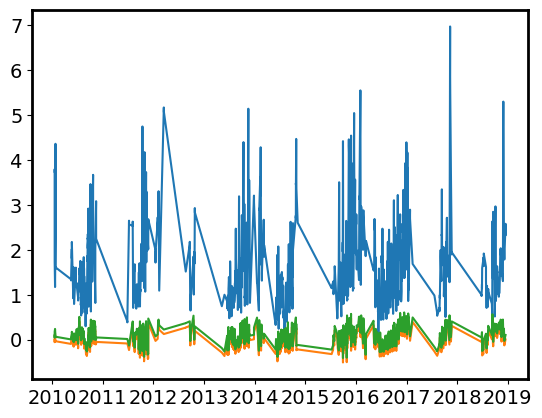

In [150]:
# uncomment cell magics to plot interactively
# %matplotlib tk

plt.figure()
plt.plot(time_data, hs_data)
plt.plot(pytmd_result_dict["list_datetimes"], pytmd_result_dict["tide_meters"])
plt.plot(time_data, pytmd_result_dict["tide_meters"]+0.1)  # just to check that there is no mishap / mismatch / shift in the time bases
plt.show()

In [151]:
# # look at the correlation
# # remember that using correlation is deceiving though; better to use the coefficient of determinatoin
# 
# correlation_tide_meters = scipy.stats.pearsonr(hs_data, pytmd_result_dict["tide_meters"])
# print(f"{correlation_tide_meters.confidence_interval(confidence_level=0.95) = }")
# 
# correlation_tide_speed = scipy.stats.pearsonr(hs_data, np.sqrt(pytmd_result_dict["tide_current_u_cm_per_s"]**2 + pytmd_result_dict["tide_current_v_cm_per_s"]**2))
# print(f"{correlation_tide_speed.confidence_interval(confidence_level=0.95) = }")

In [152]:
# -------------------- 
linregress_result = scipy.stats.linregress(pytmd_result_dict["tide_current_u_cm_per_s"], hs_data)

print("---")
print("linear regression on current u speed")
print(f"{box_side_km = }")
print(f"{hs_data.shape[0] = }")
print(f"{linregress_result.rvalue = }")
coefficient_of_determination = (linregress_result.rvalue)**2
print(f"{coefficient_of_determination = }")
print(f"{linregress_result.slope = }")
print(f"{linregress_result.stderr = }")
print(f"{np.min(pytmd_result_dict['tide_current_u_cm_per_s']) = }")
print(f"{np.max(pytmd_result_dict['tide_current_u_cm_per_s']) = }")
# note the sign change: this is because the slope is negative, not positive
print(f"{linregress_result.intercept - linregress_result.slope * np.min(pytmd_result_dict['tide_current_u_cm_per_s'])}")
print(f"{linregress_result.intercept - linregress_result.slope * np.max(pytmd_result_dict['tide_current_u_cm_per_s'])}")
print(f"{1 - (linregress_result.intercept - linregress_result.slope * np.min(pytmd_result_dict['tide_current_u_cm_per_s'])) / (linregress_result.intercept - linregress_result.slope * np.max(pytmd_result_dict['tide_current_u_cm_per_s'])) = }")

# -------------------- 
linregress_result = scipy.stats.linregress(pytmd_result_dict["tide_current_v_cm_per_s"], hs_data)

print("---")
print("linear regression on current v speed")
print(f"{box_side_km = }")
print(f"{hs_data.shape[0] = }")
print(f"{linregress_result.rvalue = }")
coefficient_of_determination = (linregress_result.rvalue)**2
print(f"{coefficient_of_determination = }")
print(f"{linregress_result.slope = }")
print(f"{linregress_result.stderr = }")
print(f"{np.min(pytmd_result_dict['tide_current_v_cm_per_s']) = }")
print(f"{np.max(pytmd_result_dict['tide_current_v_cm_per_s']) = }")
# note the sign change: this is because the slope is negative, not positive
print(f"{linregress_result.intercept - linregress_result.slope * np.min(pytmd_result_dict['tide_current_v_cm_per_s'])}")
print(f"{linregress_result.intercept - linregress_result.slope * np.max(pytmd_result_dict['tide_current_v_cm_per_s'])}")
print(f"{1 - (linregress_result.intercept - linregress_result.slope * np.min(pytmd_result_dict['tide_current_v_cm_per_s'])) / (linregress_result.intercept - linregress_result.slope * np.max(pytmd_result_dict['tide_current_v_cm_per_s'])) = }")

---
linear regression on current u speed
box_side_km = 60
hs_data.shape[0] = 3091
linregress_result.rvalue = -0.10076159549456544
coefficient_of_determination = 0.01015289912661043
linregress_result.slope = -0.01068486375167832
linregress_result.stderr = 0.0018982309779300437
np.min(pytmd_result_dict['tide_current_u_cm_per_s']) = -23.65333584058261
np.max(pytmd_result_dict['tide_current_u_cm_per_s']) = 21.995559046707758
1.4786392765868352
1.9663914988722178
1 - (linregress_result.intercept - linregress_result.slope * np.min(pytmd_result_dict['tide_current_u_cm_per_s'])) / (linregress_result.intercept - linregress_result.slope * np.max(pytmd_result_dict['tide_current_u_cm_per_s'])) = 0.2480443098768086
---
linear regression on current v speed
box_side_km = 60
hs_data.shape[0] = 3091
linregress_result.rvalue = -0.12300580857067339
coefficient_of_determination = 0.015130428942125148
linregress_result.slope = -0.008629288498706927
linregress_result.stderr = 0.0012526500908697513
np.min(py

In [20]:
# # summary of results for different boxes
# 
# ---
# linear regression on current u speed
# box_side_km = 30
# hs_data.shape[0] = 825
# linregress_result.rvalue = -0.1010507694461466
# coefficient_of_determination = 0.010211258005658277
# linregress_result.slope = -0.011040894064228809
# linregress_result.stderr = 0.003789099025487154
# np.min(pytmd_result_dict['tide_current_u_cm_per_s']) = -23.65105710254276
# np.max(pytmd_result_dict['tide_current_u_cm_per_s']) = 20.147406384478973
# 1.4365899170285679
# 1.9201641125647682
# 1 - (linregress_result.intercept - linregress_result.slope * np.min(pytmd_result_dict['tide_current_u_cm_per_s'])) / (linregress_result.intercept - linregress_result.slope * np.max(pytmd_result_dict['tide_current_u_cm_per_s'])) = 0.25184003407411304
# ---
# linear regression on current v speed
# box_side_km = 30
# hs_data.shape[0] = 825
# linregress_result.rvalue = -0.11238492958165078
# coefficient_of_determination = 0.012630372397072605
# linregress_result.slope = -0.008174879302302521
# linregress_result.stderr = 0.0025194934622039477
# np.min(pytmd_result_dict['tide_current_v_cm_per_s']) = -34.14060050242025
# np.max(pytmd_result_dict['tide_current_v_cm_per_s']) = 32.49914901112955
# 1.4199237281130597
# 1.9646956371220023
# 1 - (linregress_result.intercept - linregress_result.slope * np.min(pytmd_result_dict['tide_current_v_cm_per_s'])) / (linregress_result.intercept - linregress_result.slope * np.max(pytmd_result_dict['tide_current_v_cm_per_s'])) = 0.27728056128172374
# 
# 
# 
# 
# ---
# linear regression on current u speed
# box_side_km = 35
# hs_data.shape[0] = 1106
# linregress_result.rvalue = -0.09801035096305233
# coefficient_of_determination = 0.009606028895900693
# linregress_result.slope = -0.010676249849581064
# linregress_result.stderr = 0.003262618103778536
# np.min(pytmd_result_dict['tide_current_u_cm_per_s']) = -23.65151367794006
# np.max(pytmd_result_dict['tide_current_u_cm_per_s']) = 20.148523756690118
# 1.4665332344845108
# 1.934153377557626
# 1 - (linregress_result.intercept - linregress_result.slope * np.min(pytmd_result_dict['tide_current_u_cm_per_s'])) / (linregress_result.intercept - linregress_result.slope * np.max(pytmd_result_dict['tide_current_u_cm_per_s'])) = 0.2417699384645533
# ---
# linear regression on current v speed
# box_side_km = 35
# hs_data.shape[0] = 1106
# linregress_result.rvalue = -0.10865426086416081
# coefficient_of_determination = 0.011805748403937109
# linregress_result.slope = -0.0078098859837796505
# linregress_result.stderr = 0.0021504757858252037
# np.min(pytmd_result_dict['tide_current_v_cm_per_s']) = -34.14060050242025
# np.max(pytmd_result_dict['tide_current_v_cm_per_s']) = 32.49925604395192
# 1.454316817708245
# 1.9747664993108436
# 1 - (linregress_result.intercept - linregress_result.slope * np.min(pytmd_result_dict['tide_current_v_cm_per_s'])) / (linregress_result.intercept - linregress_result.slope * np.max(pytmd_result_dict['tide_current_v_cm_per_s'])) = 0.26354998516747463
# 
# 
# 
# 
# ---
# linear regression on current u speed
# box_side_km = 40
# hs_data.shape[0] = 1451
# linregress_result.rvalue = -0.09236900284264954
# coefficient_of_determination = 0.0085320326861454
# linregress_result.slope = -0.01008566636273206
# linregress_result.stderr = 0.0028561663168348195
# np.min(pytmd_result_dict['tide_current_u_cm_per_s']) = -23.65151367794006
# np.max(pytmd_result_dict['tide_current_u_cm_per_s']) = 20.148523756690118
# 1.4980134884149825
# 1.9397660526558371
# 1 - (linregress_result.intercept - linregress_result.slope * np.min(pytmd_result_dict['tide_current_u_cm_per_s'])) / (linregress_result.intercept - linregress_result.slope * np.max(pytmd_result_dict['tide_current_u_cm_per_s'])) = 0.22773497022284084
# ---
# linear regression on current v speed
# box_side_km = 40
# hs_data.shape[0] = 1451
# linregress_result.rvalue = -0.1074289686373057
# coefficient_of_determination = 0.011540983302475211
# linregress_result.slope = -0.00777615433915532
# linregress_result.stderr = 0.0018905519093145979
# np.min(pytmd_result_dict['tide_current_v_cm_per_s']) = -34.14148386368639
# np.max(pytmd_result_dict['tide_current_v_cm_per_s']) = 32.49936062622028
# 1.4718340362401512
# 1.9900435282853137
# 1 - (linregress_result.intercept - linregress_result.slope * np.min(pytmd_result_dict['tide_current_v_cm_per_s'])) / (linregress_result.intercept - linregress_result.slope * np.max(pytmd_result_dict['tide_current_v_cm_per_s'])) = 0.26040108403642237
# 
# 
# 
# 
# ---
# linear regression on current u speed
# box_side_km = 45
# hs_data.shape[0] = 1772
# linregress_result.rvalue = -0.08930050688175994
# coefficient_of_determination = 0.007974580529339255
# linregress_result.slope = -0.00962323436963061
# linregress_result.stderr = 0.002551184725758802
# np.min(pytmd_result_dict['tide_current_u_cm_per_s']) = -23.652425581521026
# np.max(pytmd_result_dict['tide_current_u_cm_per_s']) = 20.14964074298258
# 1.5037190738897181
# 1.925236624004521
# 1 - (linregress_result.intercept - linregress_result.slope * np.min(pytmd_result_dict['tide_current_u_cm_per_s'])) / (linregress_result.intercept - linregress_result.slope * np.max(pytmd_result_dict['tide_current_u_cm_per_s'])) = 0.21894324305863244
# ---
# linear regression on current v speed
# box_side_km = 45
# hs_data.shape[0] = 1772
# linregress_result.rvalue = -0.10987003549616838
# coefficient_of_determination = 0.0120714246999293
# linregress_result.slope = -0.007835664110332085
# linregress_result.stderr = 0.0016848943989735356
# np.min(pytmd_result_dict['tide_current_v_cm_per_s']) = -34.14148386368639
# np.max(pytmd_result_dict['tide_current_v_cm_per_s']) = 32.49941199653756
# 1.464958294965728
# 1.9871339709380627
# 1 - (linregress_result.intercept - linregress_result.slope * np.min(pytmd_result_dict['tide_current_v_cm_per_s'])) / (linregress_result.intercept - linregress_result.slope * np.max(pytmd_result_dict['tide_current_v_cm_per_s'])) = 0.26277829457358237
# 
# 
# 
# 
# ---
# linear regression on current u speed
# box_side_km = 50
# hs_data.shape[0] = 2175
# linregress_result.rvalue = -0.09815606657660633
# coefficient_of_determination = 0.009634613405791175
# linregress_result.slope = -0.010630672170222517
# linregress_result.stderr = 0.0023121257077432086
# np.min(pytmd_result_dict['tide_current_u_cm_per_s']) = -23.652425581521026
# np.max(pytmd_result_dict['tide_current_u_cm_per_s']) = 20.14964074298258
# 1.4836918504338967
# 1.9493372579080381
# 1 - (linregress_result.intercept - linregress_result.slope * np.min(pytmd_result_dict['tide_current_u_cm_per_s'])) / (linregress_result.intercept - linregress_result.slope * np.max(pytmd_result_dict['tide_current_u_cm_per_s'])) = 0.23887370211856318
# ---
# linear regression on current v speed
# box_side_km = 50
# hs_data.shape[0] = 2175
# linregress_result.rvalue = -0.11992074370700681
# coefficient_of_determination = 0.014380984771241613
# linregress_result.slope = -0.008606747550621026
# linregress_result.stderr = 0.00152851401472653
# np.min(pytmd_result_dict['tide_current_v_cm_per_s']) = -34.14236663221571
# np.max(pytmd_result_dict['tide_current_v_cm_per_s']) = 32.49941199653756
# 1.4418160703813294
# 2.0153850353633804
# 1 - (linregress_result.intercept - linregress_result.slope * np.min(pytmd_result_dict['tide_current_v_cm_per_s'])) / (linregress_result.intercept - linregress_result.slope * np.max(pytmd_result_dict['tide_current_v_cm_per_s'])) = 0.28459522866241516
# 
# 
# 
# 
# ---
# linear regression on current u speed
# box_side_km = 60
# hs_data.shape[0] = 3091
# linregress_result.rvalue = -0.10076159549456544
# coefficient_of_determination = 0.01015289912661043
# linregress_result.slope = -0.01068486375167832
# linregress_result.stderr = 0.0018982309779300437
# np.min(pytmd_result_dict['tide_current_u_cm_per_s']) = -23.65333584058261
# np.max(pytmd_result_dict['tide_current_u_cm_per_s']) = 21.995559046707758
# 1.4786392765868352
# 1.9663914988722178
# 1 - (linregress_result.intercept - linregress_result.slope * np.min(pytmd_result_dict['tide_current_u_cm_per_s'])) / (linregress_result.intercept - linregress_result.slope * np.max(pytmd_result_dict['tide_current_u_cm_per_s'])) = 0.2480443098768086
# ---
# linear regression on current v speed
# box_side_km = 60
# hs_data.shape[0] = 3091
# linregress_result.rvalue = -0.12300580857067339
# coefficient_of_determination = 0.015130428942125148
# linregress_result.slope = -0.008629288498706927
# linregress_result.stderr = 0.0012526500908697513
# np.min(pytmd_result_dict['tide_current_v_cm_per_s']) = -34.14324884307206
# np.max(pytmd_result_dict['tide_current_v_cm_per_s']) = 32.4994627537285
# 1.4374411642564433
# 2.012520348961357
# 1 - (linregress_result.intercept - linregress_result.slope * np.min(pytmd_result_dict['tide_current_v_cm_per_s'])) / (linregress_result.intercept - linregress_result.slope * np.max(pytmd_result_dict['tide_current_v_cm_per_s'])) = 0.28575074284426827

In [21]:
# the tide for xr_reduced mid point during the event we observe
datetime_data_event = [datetime.datetime(2021,2,28,0,0,0) + datetime.timedelta(hours=crrt_hours) for crrt_hours in range(24*6)]
pytmd_result_dict_during_event = get_pytmd_tide_timeseries(datetime_data_event, mid_lat, mid_lon)

tidal constituents used in the present model are: list_time_constituents = ['m2', 's2', 'k1', 'o1', 'n2', 'p1', 'k2', 'q1']


In [90]:
list_most_relevant_instruments = [
    "19648",
    "200905",
    "13319",
]

event_1_start = datetime.datetime(2021, 3, 1, 0, 0, 0)
event_1__stop = datetime.datetime(2021, 3, 4, 12, 59, 59)

dict_lists_data_all = generate_lists_data(
    dict_extracted_data,
    list(dict_extracted_data),
    event_1_start,
    event_1__stop
)

In [23]:
dict_lists_data_all["19648"].keys()

dict_keys(['tll', 'lat', 'lon', 'twh', 'swh', 'tph'])

dict_lists_data_all['19648']['tll'][idx_19648] = datetime.datetime(2021, 3, 2, 18, 30, 3)


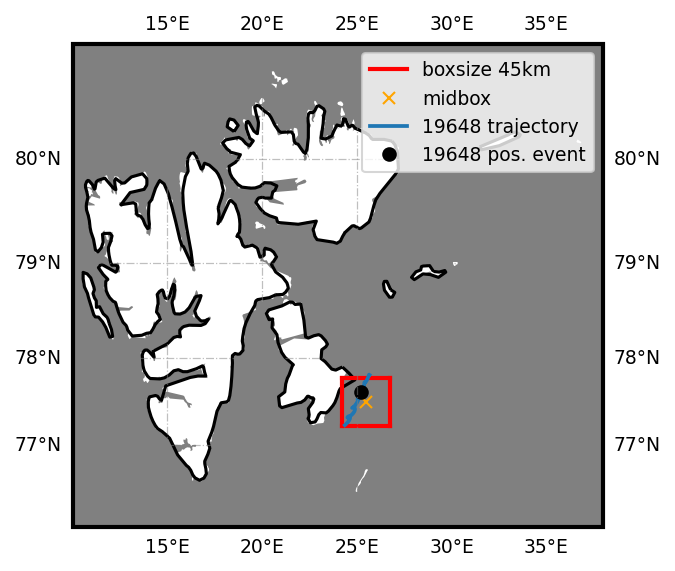

In [153]:
# show the area used by default for doing the fit, and the instruments trajectories around it

# --------------------------------------------------
# cartopy map

# First we specify Coordinate Refference System for Map Projection
# We will use Mercator, which is a cylindrical, conformal projection. 
# It has bery large distortion at high latitudes, cannot 
# fully reach the polar regions.
projection = ccrs.Mercator()

# Specify CRS, that will be used to tell the code, where should our data be plotted
crs = ccrs.PlateCarree()

# Now we will create axes object having specific projection 
# make the figure big enough
cm = 1/2.54  # centimeters in inches
plt.figure(dpi=150, figsize=(12*cm, 12*cm))
ax = plt.axes(projection=projection, frameon=True)

# Draw gridlines in degrees over Mercator map
gl = ax.gridlines(crs=crs, draw_labels=True,
                  linewidth=.6, color='gray', alpha=0.5, linestyle='-.')
gl.xlabel_style = {"size" : 9}
gl.ylabel_style = {"size" : 9}

# To plot borders and coastlines, we can use cartopy feature
import cartopy.feature as cf
ax.add_feature(cf.COASTLINE.with_scale("50m"), lw=1.5)
ax.add_feature(cf.BORDERS.with_scale("50m"), lw=0.3)

# Now, we will specify extent of our map in minimum/maximum longitude/latitude
# Note that these values are specified in degrees of longitude and degrees of latitude
# However, we can specify them in any crs that we want, but we need to provide appropriate
# crs argument in ax.set_extent
lon_min = 10
lon_max = 38
lat_min = 76
lat_max = 81

#
ax.add_feature(cf.OCEAN,facecolor=(0.5,0.5,0.5))

# xr_reduced.plot.scatter(x="longitude", y="latitude", transform=ccrs.PlateCarree())
plt.plot([mid_lon-lon_halfside, mid_lon+lon_halfside], [mid_lat-lat_halfside, mid_lat-lat_halfside], color="r", linewidth=2.0, transform=ccrs.PlateCarree())
plt.plot([mid_lon-lon_halfside, mid_lon+lon_halfside], [mid_lat+lat_halfside, mid_lat+lat_halfside], color="r", linewidth=2.0, transform=ccrs.PlateCarree())
plt.plot([mid_lon-lon_halfside, mid_lon-lon_halfside], [mid_lat-lat_halfside, mid_lat+lat_halfside], color="r", linewidth=2.0, transform=ccrs.PlateCarree())
plt.plot([mid_lon+lon_halfside, mid_lon+lon_halfside], [mid_lat-lat_halfside, mid_lat+lat_halfside], color="r", linewidth=2.0, transform=ccrs.PlateCarree(), label="boxsize 45km")

plt.plot([mid_lon], [mid_lat], color="orange", marker="x", label="midbox", transform=ccrs.PlateCarree(), linestyle='')

for crrt_instrument in ["19648"]:
    plt.plot(dict_lists_data_all[crrt_instrument]["lon"], dict_lists_data_all[crrt_instrument]["lat"], transform=ccrs.PlateCarree(), linewidth=1.8, label="19648 trajectory")

idx_19648 = 64+12
print(f"{dict_lists_data_all['19648']['tll'][idx_19648] = }")
plt.plot(dict_lists_data_all["19648"]["lon"][idx_19648], dict_lists_data_all["19648"]["lat"][idx_19648], transform=ccrs.PlateCarree(), marker="o", color="k", label="19648 pos. event", linestyle='')

plt.legend(loc="upper right", prop={'size': 9})

# crs is PlateCarree -> we are explicitly telling axes, that we are creating bounds that are in degrees
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=crs)
# plt.title(f"title")
ax.set_title("")

plt.tight_layout()

plt.savefig("map_extent_19648_sat.png")
plt.savefig("map_extent_19648_sat.pdf")

plt.show()

In [ ]:
event_1_start = datetime.datetime(2021, 3, 1, 0, 0, 0)
event_1__stop = datetime.datetime(2021, 3, 3, 23, 59, 59)

dict_lists_data_all = generate_lists_data(
    dict_extracted_data,
    list(dict_extracted_data),
    event_1_start,
    event_1__stop
)

In [24]:
# # NOTE: this cell will take long time! (up to a few hours)
# # parallelized in the cell below: use it instead
# 
# # the time and positions of the buoy 19648: predict the tide at each of the specific locations following the buoy (based on the GPS information)
# 
# # no need for lists for the time, lat, lon, these are the ones in teh dict_lists_data_all
# list_tide_19648_u = []
# list_tide_19648_v = []
# list_tide_19648_m = []
# 
# for (crrt_time, crrt_lat, crrt_lon) in zip(dict_lists_data_all["19648"]["tll"],dict_lists_data_all["19648"]["lat"],dict_lists_data_all["19648"]["lon"]):
#     crrt_dict_tide_19648 = get_pytmd_tide_timeseries([crrt_time], crrt_lat, crrt_lon)
#     list_tide_19648_u.append(crrt_dict_tide_19648["tide_current_u_cm_per_s"].data[0])
#     list_tide_19648_v.append(crrt_dict_tide_19648["tide_current_v_cm_per_s"].data[0])
#     list_tide_19648_m.append(crrt_dict_tide_19648["tide_meters"].data[0])

In [29]:
# try to be a bit faster on machines with several CPU cores and threads: embarassingly parallel

def get_local_tide_19648(tuple_time_lat_lon):
    print(f"{tuple_time_lat_lon = }")
    crrt_dict_tide_19648 = get_pytmd_tide_timeseries([tuple_time_lat_lon[0]], tuple_time_lat_lon[1], tuple_time_lat_lon[2])
    crrt_tide_19648_u = crrt_dict_tide_19648["tide_current_u_cm_per_s"].data[0]
    crrt_tide_19648_v = crrt_dict_tide_19648["tide_current_v_cm_per_s"].data[0]
    crrt_tide_19648_m = crrt_dict_tide_19648["tide_meters"].data[0]
    # print(f"{tuple_time_lat_lon = } | {crrt_tide_19648_u = } | {crrt_tide_19648_v = } | {crrt_tide_19648_m = }")
    return (crrt_tide_19648_u, crrt_tide_19648_v, crrt_tide_19648_m)


# slow: up to 45 mins on my computer; rather load the pickled version, see under :)
# tuples_results = Parallel(n_jobs=7)(delayed(get_local_tide_19648)(crrt_in) for crrt_in in zip(dict_lists_data_all["19648"]["tll"],dict_lists_data_all["19648"]["lat"],dict_lists_data_all["19648"]["lon"]))


In [30]:
# tuples_results
# 
# [(-0.7345881011771129, 21.051355784470065, -0.3018801842441801),
#  (0.6189919821596039, 24.43156328368748, -0.3600189161154723),
#  (1.8342987140997404, 26.180088847769785, -0.3925873634643027),
#  (2.9651601053014685, 26.327391806477333, -0.3996982440178667),
#  (3.878579704749187, 24.890285220209762, -0.38134955259589476),
#  (4.568761455333556, 21.9023995589606, -0.3384503506895496),
#  (4.9188908971492795, 17.712808644433473, -0.2770953921558568),
#  (4.905140484964746, 12.456665224160227, -0.19990761685923708),
#  (4.516504249292648, 6.543693214302381, -0.11287373619261963),
#  (3.721471545610007, 0.3045678172462214, -0.021511604145902054),
#  (2.596909050160644, -5.708000017334306, 0.06535012899777105),
#  (1.2119362446497435, -11.030069556462024, 0.14267983860385552),
#  (-0.4914897358652749, -15.585050291810209, 0.20808034010252757),
#  (-2.223193459661764, -18.90485009815953, 0.25386831754705275),
#  (-3.9130915846086958, -20.88266398887188, 0.2798912192260971),
#  (-5.29891566031398, -21.13447522525022, 0.2830037077672972),
#  (-6.187752202765122, -19.95820830888856, 0.26398981536580096),
#  (-6.510769129439849, -17.32125078217271, 0.22354110888100703),
#  (-4.914461193283175, -8.875267796579282, 0.08886691092332726),
#  (-3.240639018174228, -3.7199643122516948, 0.00575032773513619),
#  (4.708348055712896, 15.530653519496845, -0.32338361726696396),
#  (5.945819116093741, 18.30786171519295, -0.3719018373332832),
#  (6.736789111446859, 19.912459352075008, -0.39829868436476284),
#  (7.033759551940606, 20.152207063223635, -0.39863419104890385),
#  (6.234558738464097, 16.495373711811144, -0.3180995603516175),
#  (5.249197419630077, 12.718316028480828, -0.24146429645679862),
#  (3.9090647784152863, 7.917416352433637, -0.14556372354164523),
#  (2.29481139275025, 2.551023812117604, -0.03915168896177708),
#  (0.3341511488506501, -3.2811599994147347, 0.07576696811966087),
#  (-1.723283809500965, -9.074085318753644, 0.1915038119421536),
#  (-3.8174716442361407, -14.177893275697008, 0.2982330396760624),
#  (-5.74900610385805, -18.365675277461495, 0.3898965788827213),
#  (-7.248567344381293, -21.582589784026023, 0.4640680254866095),
#  (-8.123670625193798, -23.630609664573043, 0.5146432408963788),
#  (-8.266068630881339, -24.41498413155916, 0.5391232253578612),
#  (-7.648210497237771, -23.95549945687675, 0.5354800015368677),
#  (-6.375362890498735, -22.292985793863902, 0.5042261614573225),
#  (-4.623710940018699, -19.43471446867695, 0.44668688501790943),
#  (-2.5303419311271385, -15.540881883235821, 0.36771484605298593),
#  (-0.17969681582055624, -10.653985485922508, 0.2688867954052412),
#  (2.3746222000377224, -4.859998597993183, 0.15413362222695384),
#  (4.8546593158096005, 1.1685383815503896, 0.03549615668524567),
#  (7.242609504437168, 7.37486239089445, -0.08572187318321088),
#  (9.31602590655799, 13.294159980661348, -0.20210303579883887),
#  (10.829638040159516, 18.22272983632139, -0.30131234906420906),
#  (11.736466108345768, 22.068914057042182, -0.38337409222927965),
#  (11.898008997353761, 24.448656148235813, -0.44077833416599427),
#  (11.317801115302197, 25.25084142283529, -0.4707042891917085),
#  (10.064457329239117, 24.476480118514594, -0.4713925051420957),
#  (8.224444568132405, 22.24113860938133, -0.44396047239772013),
#  (5.964048970859676, 18.726224157025747, -0.39078704146700477),
#  (3.4218367263595573, 14.17710940954393, -0.31643172100282),
#  (0.7357686202211349, 8.902577867041924, -0.226451682996646),
#  (-1.9997387873006471, 3.1815175169184036, -0.12623822682436492),
#  (-4.550600635589237, -2.416868118414537, -0.026477336018446256),
#  (-6.881389971156904, -7.869566062533449, 0.07201900907620705),
#  (-8.736881613920675, -12.546245669167142, 0.15582124741395273),
#  (-10.158387225072502, -16.611490625993877, 0.22631253026208256),
#  (-11.132932010808222, -19.82458208751706, 0.2777353402400654),
#  (-11.640959082818366, -21.81231038908382, 0.30572476573682167),
#  (-11.528829497507722, -22.649085920229755, 0.31062625748760286),
#  (-10.913369420641395, -22.138662814930086, 0.292605609092416),
#  (-3.5164654203601593, -5.270894286802857, 0.03278640628719067),
#  (-0.7381870610647694, 0.8683343972518636, -0.05433295524678952),
#  (2.1946428451482376, 7.171842883567413, -0.14197367352826876),
#  (7.291916331803217, 17.76033112165186, -0.2874973381268993),
#  (8.993394490087853, 21.197568040260666, -0.33282897339300155),
#  (10.0045855641135, 23.119578835008628, -0.3538413295655062),
#  (10.195693439245947, 23.372107310447745, -0.34948122928803604),
#  (9.691833374993113, 22.037448660996127, -0.31883273798072675),
#  (8.509605632168388, 19.156491111688393, -0.2634574576466803),
#  (6.736879774817748, 14.87938995981911, -0.1857372371722352),
#  (4.57915063916558, 9.639562576426007, -0.09314375645864387),
#  (2.1161742627974496, 3.5915876979039076, 0.011508435165918134),
#  (-0.5527318939522297, -2.984258822355736, 0.12265994047015574),
#  (-3.1073183677737584, -9.224033012718209, 0.22499143443166458),
#  (-5.691208902590001, -15.216256552733956, 0.3214361903881007),
#  (-8.131613342339486, -20.28209736634031, 0.40332609567474553),
#  (-10.454195584846339, -23.957397497563868, 0.4649127761543881),
#  (-12.833505871860304, -26.3290777841995, 0.5048910006149595),
#  (-14.590842722000817, -27.387655290833425, 0.518404041931647),
#  (-15.44307723530046, -26.749220156194493, 0.505842589787346),
#  (-15.199210983747252, -24.32737705849438, 0.46845161273283176),
#  (-13.839439439109471, -20.142619823919397, 0.406637915740471),
#  (-11.616290427231746, -14.57676673634761, 0.3237036600484366),
#  (-8.259082998731937, -7.932128936112407, 0.22338048689173876),
#  (-3.8117327296812467, -0.32382399723219885, 0.10879312193557705),
#  (1.2736817003141283, 7.469534247101596, -0.008804101886788807),
#  (6.875274010478879, 15.16581576185877, -0.12853073462435816),
#  (12.405337866627386, 21.973462461268884, -0.2416383558823517),
#  (17.372760882380142, 27.423365219473734, -0.3422502864704107),
#  (21.053859102776435, 30.936491980913274, -0.4207149394706265),
#  (23.27322534648792, 32.487909397150254, -0.47579693852460125),
#  (24.122153939187598, 32.25538304393535, -0.5028089654621788),
#  (21.91573097426175, 26.58388493805404, -0.47332034850893573),
#  (17.54620928256905, 20.738767250200677, -0.41520143086710637),
#  (13.540684442038916, 14.522161273019593, -0.34066597073211546),
#  (9.018880989504895, 7.500411828578919, -0.25067239666894475),
#  (4.080397400972165, -0.06404905666232619, -0.1509586733131013),
#  (-0.8456689369445216, -7.560645476580775, -0.0519423133497384),
#  (-5.890220052057534, -15.060242371469064, 0.04532223330708801),
#  (-10.778099184116908, -21.884568259523203, 0.13069001131239527),
#  (-21.416144764725225, -33.48921929102805, 0.2601368454158692),
#  (-26.741327601065336, -37.03199507828417, 0.2954499867768943),
#  (-31.17301921719202, -38.41697467414922, 0.31097736445737745),
#  (-34.85346763152951, -36.458746890385754, 0.30582643977485585),
#  (-36.505884932533505, -31.617281915605215, 0.28131849371005185),
#  (-35.30210441054936, -24.08524542491802, 0.23925392673716406),
#  (-32.20901428878854, -14.604826808439283, 0.18361116652234546),
#  (-26.788998552279445, -3.8491581254194736, 0.11405627894982114),
#  (-19.451231676680546, 6.9304939371187775, 0.03866590370331571),
#  (-10.253213333209526, 17.59186291260078, -0.041692523865780665),
#  (-0.8145763020963366, 26.680493456702294, -0.11647259881484558),
#  (8.868907399772336, 34.08213781732876, -0.18448768376961075),
#  (17.644445880865955, 38.76092633926122, -0.23635426910324264),
#  (24.933645834461654, 40.50247725913001, -0.26781860679183545),
#  (30.13851427353071, 39.282648848104024, -0.2762074633500689),
#  (32.791800440957424, 35.267051405068415, -0.2596923319241534),
#  (33.09617279510266, 29.09330334090842, -0.22049412102149718),
#  (31.202860534159083, 21.046986290414857, -0.16065467743300565),
#  (27.27485023381994, 11.702058366751729, -0.08402796558702905),
#  (21.88041664736863, 2.259863304360169, -0.0005890768015638509),
#  (15.179706054119652, -7.204016485574183, 0.08822747293162257),
#  (7.35171767374493, -16.157601415333136, 0.1761641133928603),
#  (-0.995396430547355, -23.89594851514293, 0.2548078263762123),
#  (-9.474605623391575, -30.104108713018487, 0.3209039146939164),
#  (-18.02332833213074, -34.579145981602224, 0.37317019101473603),
#  (-25.370210343684214, -36.9850708035581, 0.40688267838069037),
#  (-31.40660887941472, -36.123434618324794, 0.42130502718496465),
#  (-36.330487346752015, -32.998783165856516, 0.416304923612707),
#  (-41.064638628234206, -27.672736046305378, 0.39140331770541414),
#  (-44.35591503803786, -21.56539339678668, 0.34724469813267095),
#  (-42.66132684347055, -13.230435212075033, 0.28403935400590863)]

[(-0.7345881011771129, 21.051355784470065, -0.3018801842441801),
 (0.6189919821596039, 24.43156328368748, -0.3600189161154723),
 (1.8342987140997404, 26.180088847769785, -0.3925873634643027),
 (2.9651601053014685, 26.327391806477333, -0.3996982440178667),
 (3.878579704749187, 24.890285220209762, -0.38134955259589476),
 (4.568761455333556, 21.9023995589606, -0.3384503506895496),
 (4.9188908971492795, 17.712808644433473, -0.2770953921558568),
 (4.905140484964746, 12.456665224160227, -0.19990761685923708),
 (4.516504249292648, 6.543693214302381, -0.11287373619261963),
 (3.721471545610007, 0.3045678172462214, -0.021511604145902054),
 (2.596909050160644, -5.708000017334306, 0.06535012899777105),
 (1.2119362446497435, -11.030069556462024, 0.14267983860385552),
 (-0.4914897358652749, -15.585050291810209, 0.20808034010252757),
 (-2.223193459661764, -18.90485009815953, 0.25386831754705275),
 (-3.9130915846086958, -20.88266398887188, 0.2798912192260971),
 (-5.29891566031398, -21.13447522525022, 

In [33]:
# with open("tuples_results_19648.pkl", "bw") as fh:
#     pkl.dump(tuples_results, fh)

In [34]:
with open("tuples_results_19648.pkl", "br") as fh:
    tuples_results = pkl.load(fh)

In [41]:
list_times_19648 = dict_lists_data_all["19648"]["tll"]
list_tide_u_cm_per_s_19648 = [crrt_u for (crrt_u, _, _) in tuples_results]
list_tide_v_cm_per_s_19648 = [crrt_v for (_, crrt_v, _) in tuples_results]
list_tide_tide_m_19648 = [crrt_m for (_, _, crrt_m) in tuples_results]
print("")

/tmp/ipykernel_17068/603252361.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=65)


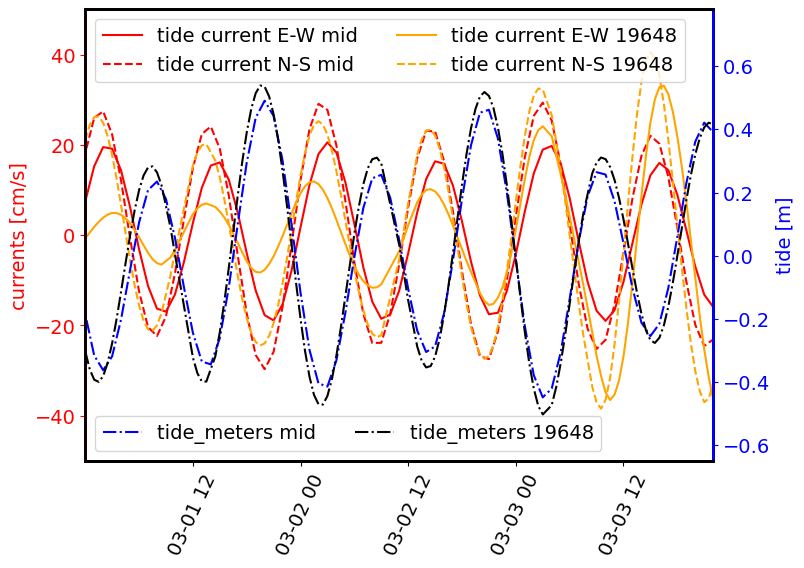

In [50]:
plt.rcParams.update({'font.size': 14})

cm = 1/2.54  # centimeters in inches
fig = plt.figure(dpi=100, figsize=(21*cm, 15*cm))
ax = fig.add_subplot(111)

# -------------------- 
ax.plot(datetime_data_event, pytmd_result_dict_during_event["tide_current_u_cm_per_s"], label="tide current E-W mid", color="r", linestyle="-")
ax.plot(datetime_data_event, pytmd_result_dict_during_event["tide_current_v_cm_per_s"], label="tide current N-S mid", color="r", linestyle="--")
# 
ax.plot(list_times_19648, list_tide_u_cm_per_s_19648, label="tide current E-W 19648", color="orange", linestyle="-")
ax.plot(list_times_19648, list_tide_v_cm_per_s_19648, label="tide current N-S 19648", color="orange", linestyle="--")

ax.set_ylim([-50, 50])
# ax.set_yticks([-30, -15, 0, 15, 30])
ax.set_ylabel("currents [cm/s]")
ax.legend(loc="upper left", ncol=2)

ax.set_xlim([dict_lists_data_all["19648"]["twh"][0], dict_lists_data_all["19648"]["twh"][-1]])
ax.set_xticklabels(ax.get_xticklabels(), rotation=65)

# -------------------- 
ax2 = ax.twinx()

ax2.plot(datetime_data_event, pytmd_result_dict_during_event["tide_meters"], label="tide_meters mid", color="b", linestyle="-.")
# 
ax2.plot(list_times_19648, list_tide_tide_m_19648, label="tide_meters 19648", color="k", linestyle="-.")

ax2.set_ylim([-0.65, 0.78])
ax2.set_ylabel("tide [m]")
# ax2.set_yticks([0.0, 0.15, 0.30, 0.45])
# 
ax.spines['left'].set_color('red')
ax.yaxis.label.set_color('red')
ax.tick_params(axis='y', colors='red')
# 
ax2.spines['right'].set_color('blue')
ax2.yaxis.label.set_color('blue')
ax2.tick_params(axis='y', colors='blue')
# 
ax2.legend(loc="lower left", ncol=3)

# ax2.axvspan(datetime.datetime(2021,3,1,10), datetime.datetime(2021,3,1,14), alpha=0.5, color='grey')
# ax2.axvspan(datetime.datetime(2021,3,1,21), datetime.datetime(2021,3,2,2), alpha=0.5, color='grey')
# ax2.axvspan(datetime.datetime(2021,3,2,10), datetime.datetime(2021,3,2,14), alpha=0.5, color='grey')
# ax2.axvspan(datetime.datetime(2021,3,2,20), datetime.datetime(2021,3,3,1), alpha=0.5, color='grey')
# ax2.axvspan(datetime.datetime(2021,3,3,9), datetime.datetime(2021,3,3,13), alpha=0.5, color='grey')

plt.tight_layout()

# -------------------- 

plt.savefig("tide_elevation_current.pdf")
plt.savefig("tide_elevation_current.png")

In [53]:
linregress_result = scipy.stats.linregress(pytmd_result_dict["tide_current_v_cm_per_s"], hs_data)

max_swh_19648 = np.max(dict_lists_data_all["19648"]["swh"])
scale_average_swh_to_19648 = max_swh_19648 / (linregress_result.intercept + np.min(list_tide_v_cm_per_s_19648) * linregress_result.slope)

1 - np.min(linregress_result.intercept + linregress_result.slope * np.array(list_tide_v_cm_per_s_19648))/np.max(linregress_result.intercept + linregress_result.slope * np.array(list_tide_v_cm_per_s_19648)) = 0.30409919231601856


/tmp/ipykernel_17068/3433329414.py:53: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=65)


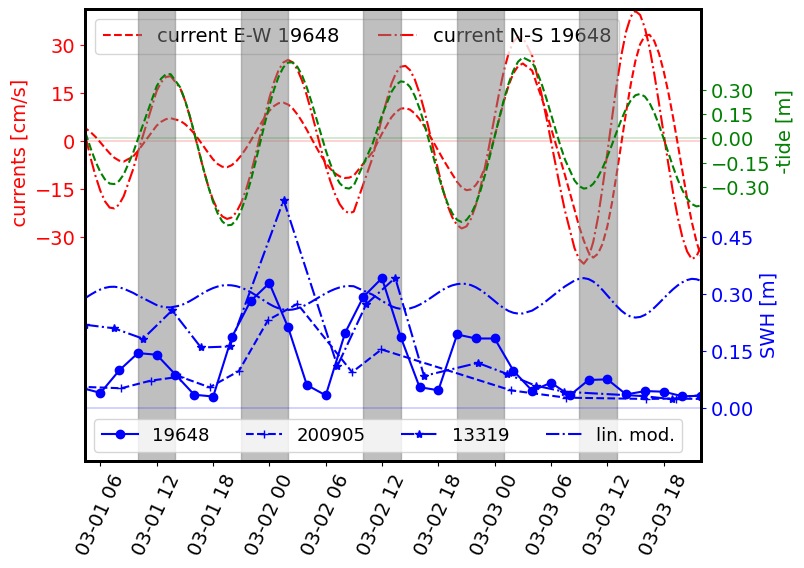

In [60]:
plt.rcParams.update({'font.size': 14})

cm = 1/2.54  # centimeters in inches
fig = plt.figure(dpi=100, figsize=(21*cm, 15*cm))
ax = fig.add_subplot(111)

# ax.plot(datetime_data_event, pytmd_result_dict_during_event["tide_current_u_cm_per_s"], color="r", linestyle="--", label="current E-W")
# ax.plot(datetime_data_event, pytmd_result_dict_during_event["tide_current_v_cm_per_s"], color="r", linestyle="-.", label="current N-S")
ax.plot(list_times_19648, list_tide_u_cm_per_s_19648, color="r", linestyle="--", label="current E-W 19648")
ax.plot(list_times_19648, list_tide_v_cm_per_s_19648, color="r", linestyle="-.", label="current N-S 19648")
ax.axhline(y=0, color="r", linewidth=0.25)

list_markers = ["o", "+", "*"]
list_styles = ["-", "--", "-."]

ax2 = ax.twinx()
for crrt_index, crrt_instrument in enumerate(["19648", "200905", "13319"]):
    ax2.plot(
        # dict_lists_data_relevant[crrt_instrument]["twh"], dict_lists_data_relevant[crrt_instrument]["swh"],
        dict_lists_data_all[crrt_instrument]["twh"], np.array(dict_lists_data_all[crrt_instrument]["swh"]),
        marker=list_markers[crrt_index], linestyle=list_styles[crrt_index], alpha=1.0,
        color="blue",
        label=instrument_label(crrt_instrument).split(" ")[0]
    )

ax2.plot(
    # dict_lists_data_all["19648"]["twh"], scale_average_swh_to_19648 * (linregress_result.intercept + linregress_result.slope * pytmd_result_dict_19648["tide_current_v_cm_per_s"]),
    # datetime_data_event, scale_average_swh_to_19648 * (linregress_result.intercept + linregress_result.slope * pytmd_result_dict_during_event["tide_current_v_cm_per_s"]),
    list_times_19648, scale_average_swh_to_19648 * (linregress_result.intercept + linregress_result.slope * np.array(list_tide_v_cm_per_s_19648)),
    color="blue",
    linestyle="-.",
    label="lin. mod."
)
ax2.axhline(y=0, color="blue", linewidth=0.25)

# print(f"{1 - np.min(linregress_result.intercept + linregress_result.slope * pytmd_result_dict_during_event['tide_current_v_cm_per_s'])/np.max(linregress_result.intercept + linregress_result.slope * pytmd_result_dict_during_event['tide_current_v_cm_per_s']) = }")
print(f"{1 - np.min(linregress_result.intercept + linregress_result.slope * np.array(list_tide_v_cm_per_s_19648))/np.max(linregress_result.intercept + linregress_result.slope * np.array(list_tide_v_cm_per_s_19648)) = }")

ax3 = ax.twinx()
ax3.plot(list_times_19648, -np.array(list_tide_tide_m_19648), color="g", linestyle="--", label="tide")
ax3.axhline(y=0, color="green", linewidth=0.25)

ax.set_ylim([-100, 41])
ax.set_yticks([-30, -15, 0, 15, 30])
ax.set_ylabel("                           currents [cm/s]")
ax.legend(loc="upper left", ncol=2)

ax.spines['left'].set_color('red')
ax.yaxis.label.set_color('red')
ax.tick_params(axis='y', colors='red')

ax.set_xlim([dict_lists_data_all[crrt_instrument]["twh"][0], dict_lists_data_all[crrt_instrument]["twh"][-1]])
ax.set_xticklabels(ax.get_xticklabels(), rotation=65)

ax2.set_ylim([-0.14, 1.05])
ax2.set_ylabel("SWH [m]                          ")
ax2.set_yticks([0.0, 0.15, 0.30, 0.45])

ax2.axvspan(datetime.datetime(2021,3,1,10), datetime.datetime(2021,3,1,14), alpha=0.5, color='grey')
ax2.axvspan(datetime.datetime(2021,3,1,21), datetime.datetime(2021,3,2,2), alpha=0.5, color='grey')
ax2.axvspan(datetime.datetime(2021,3,2,10), datetime.datetime(2021,3,2,14), alpha=0.5, color='grey')
ax2.axvspan(datetime.datetime(2021,3,2,20), datetime.datetime(2021,3,3,1), alpha=0.5, color='grey')
ax2.axvspan(datetime.datetime(2021,3,3,9), datetime.datetime(2021,3,3,13), alpha=0.5, color='grey')

# ax2.spines['right'].set_color('blue')
ax2.yaxis.label.set_color('blue')
ax2.tick_params(axis='y', colors='blue')

ax3.set_ylim([-2.0, 0.8])
ax3.set_ylabel("                                  -tide [m]")
ax3.set_yticks([-0.3, -0.15, 0.0, 0.15, 0.30])

# ax2.spines['right'].set_color('blue')
ax3.yaxis.label.set_color('green')
ax3.tick_params(axis='y', colors='green')

plt.tight_layout()

ax2.legend(loc="lower left", ncol=4, prop={'size':13})

plt.savefig("tide_linreg_modulation.pdf")
plt.savefig("tide_linreg_modulation.png")

In [ ]:
# TODO: do this analysis exactly at the location of the buoy? (following the buoy location in the pytmd analysis?)
# TODO: make it clear that "ballpark" analysis; suggest putting a buoy there when it is open water and more when there is sea ice?